In [10]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

# 0 = Empty, 1 = Goal, 2 = Pitfall
grid = [
    [0, 0, 0, 1],
    [0, 0, 0, 2],
    [0, 0, 0, 0]
]

rows, cols = 3, 4

gamma = 0.9
threshold = 0.001

# Rewards
rewards = np.full((rows, cols), -1.0)
rewards[0][3] = 10.0
rewards[1][3] = -10.0

print("Grid:")
for row in grid:
    print(row)

print("\nReward Map:")
print(rewards)

Grid:
[0, 0, 0, 1]
[0, 0, 0, 2]
[0, 0, 0, 0]

Reward Map:
[[ -1.  -1.  -1.  10.]
 [ -1.  -1.  -1. -10.]
 [ -1.  -1.  -1.  -1.]]


In [11]:
def value_iteration(grid, rewards, gamma=0.9, threshold=0.001):
    rows = len(grid)
    cols = len(grid[0])

    V = np.zeros((rows, cols))
    iteration = 0

    while True:
        delta = 0
        new_V = np.copy(V)

        for r in range(rows):
            for c in range(cols):

                # Goal and pitfall values are fixed
                if grid[r][c] != 0:
                    new_V[r, c] = rewards[r, c]
                else:
                    next_values = []

                    # Up, Down, Left, Right
                    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nr, nc = r + dr, c + dc

                        if 0 <= nr < rows and 0 <= nc < cols:
                            next_values.append(V[nr, nc])
                        else:
                            # If the agent hits a wall, it stays in the same square
                            next_values.append(V[r, c])

                    new_V[r, c] = rewards[r, c] + gamma * max(next_values)

                delta = max(delta, abs(V[r, c] - new_V[r, c]))

        V = new_V
        iteration += 1

        if delta < threshold:
            break

    return V, iteration


V, iteration = value_iteration(grid, rewards, gamma, threshold)

print(f"Converged in {iteration} iterations.")
print("\nValue Map:")
print(np.round(V, 2))

Converged in 7 iterations.

Value Map:
[[  4.58   6.2    8.    10.  ]
 [  3.12   4.58   6.2  -10.  ]
 [  1.81   3.12   4.58   3.12]]


In [12]:
def get_policy(grid, V):
    rows = len(grid)
    cols = len(grid[0])

    actions = ['↑', '↓', '←', '→']
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    policy = []

    for r in range(rows):
        row_policy = []

        for c in range(cols):
            if grid[r][c] == 1:
                row_policy.append("G")
                continue

            if grid[r][c] == 2:
                row_policy.append("P")
                continue

            best_value = -float("inf")
            best_action = ""

            for i, (dr, dc) in enumerate(directions):
                nr, nc = r + dr, c + dc

                if 0 <= nr < rows and 0 <= nc < cols:
                    value = V[nr, nc]
                else:
                    value = V[r, c]

                if value > best_value:
                    best_value = value
                    best_action = actions[i]

            row_policy.append(best_action)

        policy.append(row_policy)

    return policy


policy = get_policy(grid, V)

print("Final Policy:")
for row in policy:
    print("  ".join(row))

Final Policy:
→  →  →  G
↑  ↑  ↑  P
↑  ↑  ↑  ←


In [13]:
def simulate_path(grid, policy, start, max_steps=20):
    direction_map = {
        '↑': (-1, 0),
        '↓': (1, 0),
        '←': (0, -1),
        '→': (0, 1)
    }

    r, c = start
    path = [(r, c)]

    for _ in range(max_steps):
        if grid[r][c] in [1, 2]:
            break

        action = policy[r][c]
        dr, dc = direction_map[action]

        r, c = r + dr, c + dc
        path.append((r, c))

        if grid[r][c] in [1, 2]:
            break

    return path


start_points = [(2, 0), (2, 1), (1, 0), (0, 0)]

for start in start_points:
    path = simulate_path(grid, policy, start)
    print(f"Start {start}: {path}")

Start (2, 0): [(2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3)]
Start (2, 1): [(2, 1), (1, 1), (0, 1), (0, 2), (0, 3)]
Start (1, 0): [(1, 0), (0, 0), (0, 1), (0, 2), (0, 3)]
Start (0, 0): [(0, 0), (0, 1), (0, 2), (0, 3)]


In [14]:
gamma_values = [0.5, 0.7, 0.9, 0.95]
gamma_results = []

for g in gamma_values:
    V_temp, iter_temp = value_iteration(grid, rewards, gamma=g, threshold=threshold)

    gamma_results.append({
        "gamma": g,
        "iterations": iter_temp,
        "value_at_start_2_0": round(V_temp[2, 0], 3),
        "value_near_goal_0_2": round(V_temp[0, 2], 3)
    })

gamma_table = pd.DataFrame(gamma_results)
gamma_table

,gamma,iterations,value_at_start_2_0,value_near_goal_0_2
0,0.50,7,-1.625,4.0
1,0.70,7,-1.092,6.0
2,0.90,7,1.810,8.0
3,0.95,7,3.213,8.5


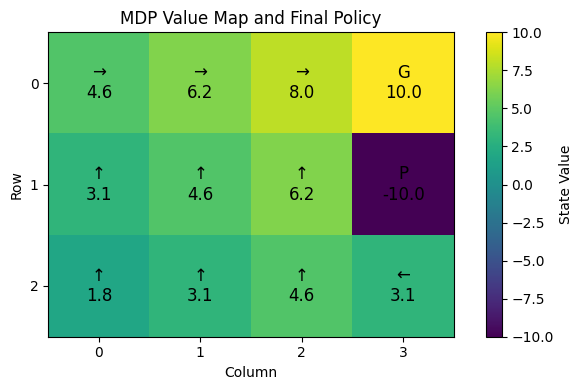

In [15]:
plt.figure(figsize=(7, 4))
plt.imshow(V)

for r in range(rows):
    for c in range(cols):
        if grid[r][c] == 1:
            label = f"G\n{V[r, c]:.1f}"
        elif grid[r][c] == 2:
            label = f"P\n{V[r, c]:.1f}"
        else:
            label = f"{policy[r][c]}\n{V[r, c]:.1f}"

        plt.text(c, r, label, ha="center", va="center", fontsize=12)

plt.title("MDP Value Map and Final Policy")
plt.xlabel("Column")
plt.ylabel("Row")
plt.xticks(range(cols))
plt.yticks(range(rows))
plt.colorbar(label="State Value")
plt.tight_layout()
plt.show()

In [16]:
def simulate_monty_hall(simulations=10000):
    stay_wins = 0
    switch_wins = 0

    for _ in range(simulations):
        doors = ["goat", "goat", "car"]
        random.shuffle(doors)

        choice = random.randrange(3)

        # Host opens a goat door that is not the player's choice
        possible_host_doors = [
            i for i in range(3)
            if i != choice and doors[i] == "goat"
        ]

        host_open = random.choice(possible_host_doors)

        # Stay strategy
        if doors[choice] == "car":
            stay_wins += 1

        # Switch strategy
        switch_choice = [
            i for i in range(3)
            if i != choice and i != host_open
        ][0]

        if doors[switch_choice] == "car":
            switch_wins += 1

    stay_rate = stay_wins / simulations
    switch_rate = switch_wins / simulations

    return stay_rate, switch_rate


simulations = 10000
stay_rate, switch_rate = simulate_monty_hall(simulations)

print(f"Number of simulations: {simulations}")
print(f"Stay Strategy Win Rate: {stay_rate:.2%}")
print(f"Switch Strategy Win Rate: {switch_rate:.2%}")

if switch_rate > stay_rate:
    print("Conclusion: Switching is better than staying.")
else:
    print("Conclusion: Staying is better than switching.")

Number of simulations: 10000
Stay Strategy Win Rate: 33.14%
Switch Strategy Win Rate: 66.86%
Conclusion: Switching is better than staying.


In [17]:
simulation_sizes = [100, 1000, 5000, 10000]
simulation_results = []

for n in simulation_sizes:
    stay, switch = simulate_monty_hall(n)

    simulation_results.append({
        "simulations": n,
        "stay_win_rate": round(stay, 4),
        "switch_win_rate": round(switch, 4),
        "better_strategy": "Switch" if switch > stay else "Stay"
    })

simulation_table = pd.DataFrame(simulation_results)
simulation_table

,simulations,stay_win_rate,switch_win_rate,better_strategy
0,100,0.3500,0.6500,Switch
1,1000,0.3210,0.6790,Switch
2,5000,0.3352,0.6648,Switch
3,10000,0.3297,0.6703,Switch


In [18]:
theory_table = pd.DataFrame({
    "strategy": ["Stay", "Switch"],
    "theoretical_probability": [1/3, 2/3],
    "simulation_probability": [stay_rate, switch_rate],
    "difference": [stay_rate - 1/3, switch_rate - 2/3]
})

theory_table

,strategy,theoretical_probability,simulation_probability,difference
0,Stay,0.333333,0.3314,-0.001933
1,Switch,0.666667,0.6686,0.001933


In [19]:
def one_monty_hall_example():
    doors = ["goat", "goat", "car"]
    random.shuffle(doors)

    choice = random.randrange(3)

    possible_host_doors = [
        i for i in range(3)
        if i != choice and doors[i] == "goat"
    ]

    host_open = random.choice(possible_host_doors)

    switch_choice = [
        i for i in range(3)
        if i != choice and i != host_open
    ][0]

    print("One Monty Hall Game Example")
    print("---------------------------")
    print(f"Hidden doors: {doors}")
    print(f"Player first chooses door: {choice}")
    print(f"Host opens door: {host_open}, which has a goat")
    print(f"If the player switches, the final choice is door: {switch_choice}")

    if doors[switch_choice] == "car":
        print("Switch result: Win")
    else:
        print("Switch result: Lose")


one_monty_hall_example()

One Monty Hall Game Example
---------------------------
Hidden doors: ['goat', 'goat', 'car']
Player first chooses door: 1
Host opens door: 0, which has a goat
If the player switches, the final choice is door: 2
Switch result: Win


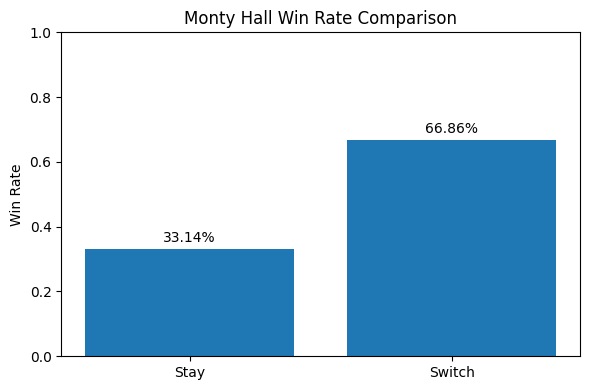

In [20]:
strategies = ["Stay", "Switch"]
win_rates = [stay_rate, switch_rate]

plt.figure(figsize=(6, 4))
plt.bar(strategies, win_rates)

for i, rate in enumerate(win_rates):
    plt.text(i, rate + 0.02, f"{rate:.2%}", ha="center")

plt.title("Monty Hall Win Rate Comparison")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()